<a href="https://colab.research.google.com/github/casangi/examples/blob/CAS-13662/community/ALMAephemimagingVenusMfsMosaic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ALMA ephemeris object (21P/Giacobini-Zinner) cube mosaic imaging:

## Use 'TRACKFIELD' in phasecenter parameter

Original Author(s): ttsutsum@nrao.edu

## Description

The following demo describes cube imaging of ALMA observation of Comet Giacobini-Zinner. 
For imaigng of the sources that move significantly during the observations, proper ephemeris data need to be used. For the current ALMA data, the epehemeris tables used to track the source during the observation generally included in the ASDM. The task, importasdm attaches the ephemeris table(s) in FIELD sub-table in the generated MS. Here we starts from such MS data and also uses a short cut option called 'TRACKFIELD' in tclean to use the attached ephemeris table(s).

## Data

The comet dataset used here consists of the two MSes from Band 7 observations separated by 6 days using ACA. Each MS has an ephemeris table approriated for the observation attached. 
The data is available in the [casatestdata-large repository](https://open-bitbucket.nrao.edu/projects/CASA/repos/casatestdata-large/browse), under [stateholders/alma/](https://open-bitbucket.nrao.edu/projects/CASA/repos/casatestdata-large/browse/stakeholder/alma)

Or at NRAO, casatestdata is accessible at /home/casa/data/casatestdata-large.

## Installation

### Install CASA
Skip this step if CASA is already installed

In [ ]:
import os
print("Installing CASA ...")
os.system('pip install casaconfig')
os.system('pip install casatools==6.7.0.31')
os.system('pip install casatasks==6.7.0.31')

In [34]:
# for Colab
mydatapath = '/content/.casa/data'
#
#mydatapath='data'

import pathlib
from casaconfig import config
if not pathlib.Path(mydatapath).exists():
  pathlib.Path(mydatapath).mkdir(parents=True)
config.measurespath=mydatapath

### Install additional modules used in this notebook

In [ ]:
import os
os.system("pip install aplpy")
os.system("pip install ipympl")
print("complete")

<b> This notebook uses functions from EphemerisObjectImagingDemoFunctions.py so that file must be present in the same directory running this notebook and need to import them </b>

In [ ]:
# if you haven't downloaded EphemerisObjectImagingDemoFuntions.py
!wget https://raw.githubusercontent.com/casangi/examples/refs/heads/CAS-13662/community/EphemerisObjectImagingDemoFunctions.py

In [36]:
from EphemerisObjectImagingDemoFunctions import *

### Import libraries

In [37]:
from casatasks import getephemtable, tclean, exportfits, listobs, imstat, imhead
from casatools import measures, quanta, table, image
import os
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib import pylab as pl
import numpy as np
import aplpy
me = measures()
qa = quanta()
tb = table()
ia = image()

## Imaging with epehemeris data attached to the MS

In order to track the ephemeris source during the observations, the proper ephemeris data is used. 
Ususally such ephemeris data table(s) are attached to the Measurement Set automatically during importadm when they are available. In tclean, the phasecenter parameter can be set to point to the ephemeris table, which can be one attached to the MS (inside FIELD sub-table directory) or an external one. In this demo, we use a shortcut option, 'TRACKFIELD' to use the internal ephemeris table without explicitly specified by ephemeris table name. The spectral frame is set to 'cubesource', which a frame of the source. Note that the frame in the resultant image will be labelled as 'REST'. 


### Obtain data
This demo uses two MS data, 2017.1.00750.T_tclean_exe1.ms (1.4GB) and 2017.1.00750.T_tclean_exe2.ms(1.1GB).

In [3]:
# At NRAO, point to the casatestdata-large directory
#inputdatapath='/home/casa/data/casatestdata-large/stakeholder/alma/'
# or Use local clone ofnn tyendata repository, e.g.
#inputdatapath='/Volumes/ssd1/casatestdata/stakeholder/alma/'

#### For Colab or for downloading the input data locally, execute 4 cells, otherwise skip them

In [38]:
# If running on Colab

# sparse-checkout of the data repository

# install git lfs
os.system('pip install git-lfs -q')
os.system('git-lfs install')
# clone the casatestdata to mytestdata
os.system('git clone --filter=blob:none --sparse https://open-bitbucket.nrao.edu/scm/casa/casatestdata-large.git mytestdata')


Updated Git hooks.
Git LFS initialized.
Cloning into 'mytestdata'...
remote: Enumerating objects: 10606, done.
remote: Counting objects: 100% (10606/10606), done.
remote: Compressing objects: 100% (5657/5657), done.
remote: Total 10606 (delta 4973), reused 10556 (delta 4948), pack-reused 0
Receiving objects: 100% (10606/10606), 1.89 MiB | 1.74 MiB/s, done.
Resolving deltas: 100% (4973/4973), done.
remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0
Receiving objects: 100% (2/2), 1.06 KiB | 1.06 MiB/s, done.


In [39]:
%cd mytestdata
os.system('git sparse-checkout set stakeholder/alma/2017.1.00750.T_tclean_exe1.ms stakeholder/alma/2017.1.00750.T_tclean_exe2.ms')

/Users/ttsutsum/SWDevel/casa_mod/examples/community/mytestdata
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (211/211), done.
remote: Total 211 (delta 0), reused 209 (delta 0), pack-reused 0
Receiving objects: 100% (211/211), 24.58 KiB | 8.19 MiB/s, done.
https://git-lfs.github.com/spec/v1 is not a valid attribute name: stakeholder/alma/.gitattributes:1
sha256:79f7502d0bda204c2994be5715262ceaae5a846268106e6e76e5c2e2cd6c3615 is not a valid attribute name: stakeholder/alma/.gitattributes:2
Filtering content: 100% (316/316), 2.43 GiB | 1.99 MiB/s, done.


In [42]:
%cd ..

/Users/ttsutsum/SWDevel/casa_mod/examples/community


In [44]:
inputdatapath='mytestdata/stakeholder/alma/'

---

In [45]:
msfile=[inputdatapath+'2017.1.00750.T_tclean_exe1.ms',inputdatapath+'2017.1.00750.T_tclean_exe2.ms']

In [46]:
# Check the data exists
from casatasks import listobs
for vis in msfile:
   listobs(vis)

In [47]:
imgname='21PGZComet-cubesrc-mosaic-trackfield'

In [48]:
delete_tcleanimages(imgname)

In [49]:
ret=tclean(vis=msfile, field='21PGiacobini-Zinner', spw=['0', '0'], \
            antenna=['0,1,2,3,4,5,6,7,8,9,10,11', '0,1,2,3,4,5,6,7,8,9'], \
            scan=['7,11,15,19,23', '8,12,16,20,24'], \
            intent='OBSERVE_TARGET#ON_SOURCE', datacolumn='data', \
            imagename=imgname, imsize=[80, 80], cell=['0.66arcsec'], \
            phasecenter='TRACKFIELD', stokes='I', specmode='cubesource', \
            nchan=1000, start='354.4452721710GHz', width='0.1221004MHz', perchanweightdensity=True, \
            gridder='mosaic', mosweight=False, \
            usepointing=True, pblimit=0.2, deconvolver='hogbom', \
            restoration=True, restoringbeam='common', pbcor=True, \
            #weighting='briggsbwtaper', robust=0.5, npixels=0, niter=30000, \
            weighting='briggsbwtaper', robust=0.5, npixels=0, niter=100, \
            threshold='0.274Jy', nsigma=0.0, usemask='auto'
            '-multithresh', sidelobethreshold=1.25, noisethreshold=5.0, \
            lownoisethreshold=2.0, negativethreshold=0.0, \
            minbeamfrac=0.1, growiterations=75, dogrowprune=True, \
            minpercentchange=1.0, fastnoise=False, restart=True, \
            calcres=True, calcpsf=True, savemodel='none', \
            parallel=False, verbose=True)
ret['iterdone']


0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%


270

### Examination of the resultant image
For displaying the resultant image, first find a peak channel and dispay that channel image.

In [50]:
# Find a peak channel
imstatres = imstat(imgname+'.image')
maxchan = imstatres['maxpos'][3]
print(maxchan)

488


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


<Figure size 2000x1000 with 0 Axes>

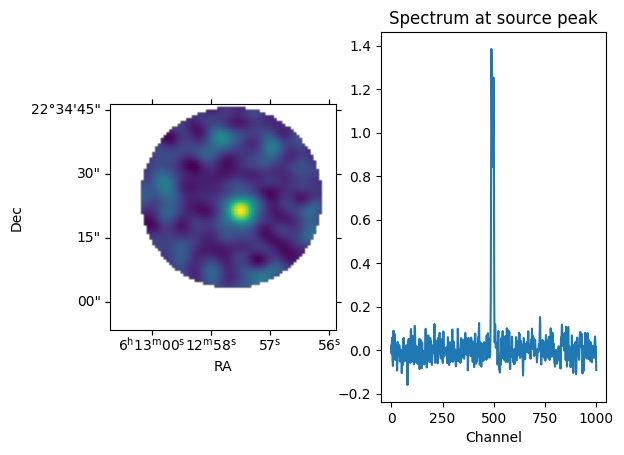

In [51]:
dispImage(f'{imgname}.image',chanslice=maxchan, useAstropy=True)

In [52]:
obsdate = imhead(f'{imgname}.image', mode='list')['date-obs']
print(obsdate)

2018/09/16/10:15:58.895999


In [53]:
ephemtab = get_attachedEphemtablepath(msfile[0],'21PGiacobini-Zinner')
ineph_dir = ephem_dir(ephemtab, obsdate,'ALMA')

In [54]:
print("Internal ephem dir = ",qa.time(ineph_dir['m0'],prec=9)[0],qa.angle(ineph_dir['m1'],prec=9)[0])
print('Image center:',printImageCenter(imgname+'.image'))

Internal ephem dir =  06:12:57.770 +022.34.20.236
Image center: ('06:12:57.770', '+022.34.20.236')


 ### Spectral information

Determine image channel frequency at the peak 

In [55]:
ia.open(f'{imgname}.image')
csys = ia.coordsys()
csysrec = csys.torecord()
ia.done()
restfreq = csysrec['spectral2']['restfreq']
print('restfreq:',restfreq)

restfreq: 354505473000.0


In [56]:
# find image frequency at the peak
specaxis=csys.findcoordinate('spectral')['pixel'][0]
pixel=csys.referencepixel()

In [57]:
pixel['numeric'][specaxis] = maxchan
print(pixel)
f_peak = csys.toworld(pixel)['numeric'][specaxis]
# this is different from what I read from the Viewer
print(f_peak,'Hz')

{'ar_type': 'absolute', 'numeric': array([ 40.,  40.,   0., 488.]), 'pw_type': 'pixel'}
354504857166.1997 Hz


The spectrum is centered around the rest freqeuncy. This roughly indicates that the 'SOURCE' 
frame trasformation is done correctly. 
Now, from the radial velocity provided in the ephemeris table, check if the frequency shift is done correctly,.

In [58]:
# reference time in mjd
mjd0=qa.quantity(obsdate,'d')['value']
print(mjd0)

58377.427764999986


In [59]:
# Access ephemeris table data
tb.open(ephemtab)
mjdcol = tb.getcol('MJD')
radc = tb.getcol('RA')
decdc = tb.getcol('DEC')
rhoc = tb.getcol('Rho')
radvel=tb.getcol('RadVel')
tb.done()

True

In [60]:
# Do linear interpolation to get the radial velocity at the reference time
radv = np.interp(mjd0,mjdcol,radvel)
qradv = qa.convert(qa.quantity(radv,'AU/d'),'km/s')
raval = np.interp(mjd0,mjdcol,radc)
decval= np.interp(mjd0,mjdcol,decdc)
rhoval = np.interp(mjd0,mjdcol,rhoc)
print(qradv)
print(qa.time(qa.quantity(raval,'deg'),prec=9),qa.angle(qa.quantity(decval,'deg'),prec=9))

{'unit': 'km/s', 'value': 3.35206559623668}
['06:12:57.610'] ['+022.34.25.174']


In [61]:
vradkmps = qradv['value']

Run imaging with outfrmae = TOPO to compare the frequency at the peak

In [62]:
img2name = '21PGZComet-cube-topo-mosaic-trackfield'
# remove images from the previous run
delete_tcleanimages(img2name)

In [63]:
ret=tclean(vis=msfile, field='21PGiacobini-Zinner', spw='0', \
            antenna='0,1,2,3,4,5,6,7,8,9,10,11', \
            scan='7,11,15,19,23', \
            intent='OBSERVE_TARGET#ON_SOURCE', datacolumn='data', \
            imagename=img2name, imsize=[80, 80], cell=['0.66arcsec'], \
            phasecenter='TRACKFIELD', stokes='I', specmode='cube', \
            nchan=1000, start='354.4452721710GHz', width='0.1221004MHz', perchanweightdensity=True, outframe='TOPO',\
            gridder='mosaic', mosweight=False, \
            usepointing=True, pblimit=0.2, deconvolver='hogbom', \
            restoration=True, restoringbeam='common', pbcor=True, \
            #weighting='briggsbwtaper', robust=0.5, npixels=0, niter=30000, \
            weighting='briggsbwtaper', robust=0.5, npixels=0, niter=100, \
            threshold='0.274Jy', nsigma=0.0, usemask='auto'
            '-multithresh', sidelobethreshold=1.25, noisethreshold=5.0, \
            lownoisethreshold=2.0, negativethreshold=0.0, \
            minbeamfrac=0.1, growiterations=75, dogrowprune=True, \
            minpercentchange=1.0, fastnoise=False, restart=True, \
            calcres=True, calcpsf=True, savemodel='none', \
            parallel=False, verbose=True)
ret['iterdone']


0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%


183

In [64]:
imstatres = imstat(img2name+'.image')
maxchantopo = imstatres['maxpos'][3]
print (f'maxchan in topo image:{maxchantopo}')

maxchan in topo image:457


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


<Figure size 2000x1000 with 0 Axes>

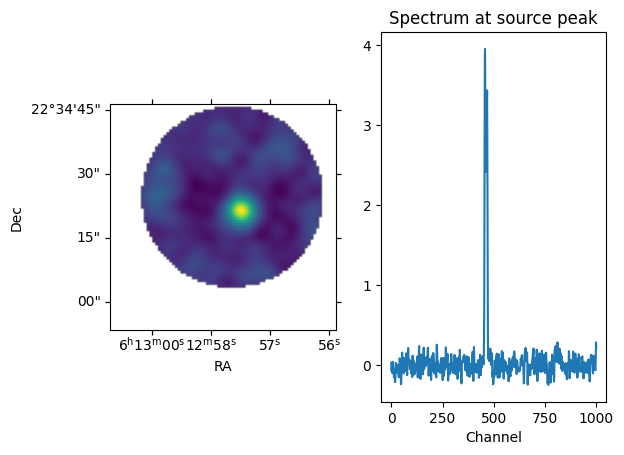

In [65]:
dispImage(f'{img2name}.image',chanslice=maxchantopo, useAstropy=True)

In [66]:
# Find a peak channel frequency in the TOPO image
ia.open(f'{img2name}.image')
csys = ia.coordsys()
ia.done()
pixel=csys.referencepixel()
pixel['numeric'][specaxis] = maxchantopo
print(pixel)
ftopo_peak = csys.toworld(pixel)['numeric'][specaxis]
print(ftopo_peak,'Hz')

{'ar_type': 'absolute', 'numeric': array([ 40.,  40.,   0., 457.]), 'pw_type': 'pixel'}
354501072053.79895 Hz


In [67]:
# geocetric radial velocity of the observatory
me.doframe(me.observatory('ALMA'))
me.doframe(me.epoch(str(mjd0)+'d'))
vobsgeo = me.measure(me.radialvelocity('TOPO', '0.0m/s'),'GEO')
print(vobsgeo)

{'m0': {'unit': 'm/s', 'value': 1.128021837932235}, 'refer': 'GEO', 'type': 'radialvelocity'}


In [68]:
# Add the source and observatory velocities. Note for the source's velocity flip the vector so it
# point back to the source
totvelmps=-1.*vradkmps*1000. + vobsgeo['m0']['value']
print('vrad=',totvelmps)
# expected shift in freq
#v/c = (f0**2 - f**2)/(f0**2 + f**2)
velperc = totvelmps/qa.constants('C')['value']
foverf0 = np.sqrt((1-velperc)/(1+velperc))
exp_fpeak = ftopo_peak*foverf0
print(f' expected SOURCE frequency (Hz) at peak shifting the topo peak frequency ({ftopo_peak}) = {exp_fpeak}')
print(f' actual peak frequency in cubesrc image = {f_peak}')
print("f_peak - exp_fpeak = ",f_peak - exp_fpeak)
# note that channel width is ~122kHz

vrad= -3350.937574398748
 expected SOURCE frequency (Hz) at peak shifting the topo peak frequency (354501072053.79895) = 354505034520.3982
 actual peak frequency in cubesrc image = 354504857166.1997
f_peak - exp_fpeak =  -177354.19848632812


In [69]:
# The same excersise using measure tool
# imaging with TOPO
me.doframe(me.observatory('ALMA'))
me.doframe(me.epoch(str(mjd0)+'d'))
print("qvrad=",qradv)
modvrad = -1.*qradv['value'] + 1.1280218377914935/1000.
mradv = me.radialvelocity('GEO',str(modvrad)+'km/s')
dop=me.todoppler('radio', mradv)
print(f'vel={mradv}')
print(f'dop={dop}')
#mfrq = me.frequency('LSRK', qa.quantity(flsrk_peak,'Hz'))
mfrq = me.frequency('TOPO', qa.quantity(ftopo_peak,'Hz'))
print(f'mfrq={mfrq}')
# use 'REST' frame to convert frequency to that of SOURCE frame
exp_f_peak = me.tofrequency('REST', dop, me.frequency('REST', qa.quantity(ftopo_peak,'Hz')))
#print('expected frequecy at the peak in rest(source) frame using LSRK peak frequency:',exp_f_peak)
print('expected SOURCE frequecy at the peak in lsrk frame using cubesrc peak frequency:',exp_f_peak)
print(f'compared to freq_peak from the cubesrc image = {f_peak} Hz')
print(f_peak - exp_f_peak['m0']['value'])

qvrad= {'unit': 'km/s', 'value': 3.35206559623668}
vel={'m0': {'unit': 'm/s', 'value': -3350.9375743988885}, 'refer': 'GEO', 'type': 'radialvelocity'}
dop={'m0': {'unit': 'm/s', 'value': -3350.9563022008015}, 'refer': 'RADIO', 'type': 'doppler'}
mfrq={'m0': {'unit': 'Hz', 'value': 354501072053.79895}, 'refer': 'TOPO', 'type': 'frequency'}
expected SOURCE frequecy at the peak in lsrk frame using cubesrc peak frequency: {'m0': {'unit': 'Hz', 'value': 354505034520.3982}, 'refer': 'REST', 'type': 'frequency'}
compared to freq_peak from the cubesrc image = 354504857166.1997 Hz
-177354.19848632812
